In [13]:
import pandas as pd
import numpy as np
import os
import json
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [14]:


DATA_PATH = '../backend/data/AQ of adoloscents - Sheet.csv' 

df = pd.read_csv(DATA_PATH)


if 'Q1' not in df.columns:
    question_cols = df.columns[0:9] 
    rename_map = {col: f'Q{i+1}' for i, col in enumerate(question_cols)}
    df = df.rename(columns=rename_map)

# Engineer Target_Category
if 'Target_Category' not in df.columns:
    def categorize_aq(score):
        if score < 2.5: return 0      # Low
        elif score < 3.5: return 1    # Medium
        else: return 2                # High
    df['Target_Category'] = df['AQ'].apply(categorize_aq)

features = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']
X = df[features]
y = df['Target_Category']

print(f"Data Loaded. Shape: {df.shape}")
df[features + ['Target_Category']].head()

Data Loaded. Shape: (222, 15)


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Target_Category
0,5,5,5,5,5,5,5,5,5,5,2
1,5,5,4,5,4,5,5,4,3,4,2
2,5,5,1,5,1,3,2,1,5,1,1
3,3,4,4,3,4,4,4,5,4,3,2
4,5,5,5,5,5,5,5,3,5,4,2


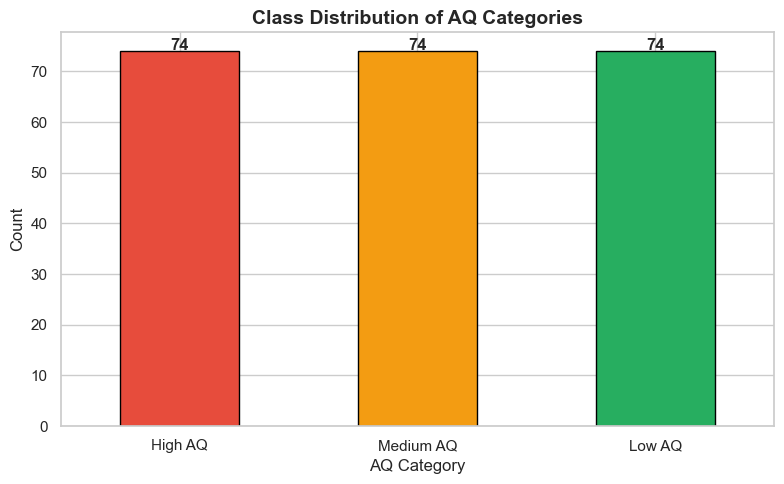


Class Distribution:
Target_Category
High AQ      74
Medium AQ    74
Low AQ       74
Name: count, dtype: int64


In [15]:
# Class distribution
class_labels = {0: 'Low AQ', 1: 'Medium AQ', 2: 'High AQ'}
class_counts = y.map(class_labels).value_counts()

plt.figure(figsize=(8, 5))
ax = class_counts.plot(kind='bar', color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='black')
plt.title('Class Distribution of AQ Categories', fontsize=14, fontweight='bold')
plt.xlabel('AQ Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nClass Distribution:\n{class_counts}")

In [16]:
# Train / Test Split  (No scaling needed for Random Forest)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train class distribution:\n{y_train.value_counts().sort_index()}")

Train size: 177 | Test size: 45
Train class distribution:
Target_Category
0    59
1    59
2    59
Name: count, dtype: int64


In [17]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features: {rf_model.n_features_in_}")

Random Forest model trained successfully!
Number of trees: 100
Number of features: 10


In [18]:
# Evaluation
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
auc_roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")

Accuracy  : 0.9556
F1 Score  : 0.9555
AUC-ROC   : 0.9993


In [19]:
# Cross Validation
cv_results = cross_validate(
    rf_model, X, y,
    cv=5,
    scoring='accuracy',
    return_train_score=False
)

cv_mean = cv_results['test_score'].mean()
cv_std  = cv_results['test_score'].std()

print(f"CV Mean Accuracy : {cv_mean:.4f}")
print(f"CV Std           : {cv_std:.4f}")

CV Mean Accuracy : 0.9732
CV Std           : 0.0326


[[14  1  0]
 [ 0 14  1]
 [ 0  0 15]]
              precision    recall  f1-score   support

         Low       1.00      0.93      0.97        15
      Medium       0.93      0.93      0.93        15
        High       0.94      1.00      0.97        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



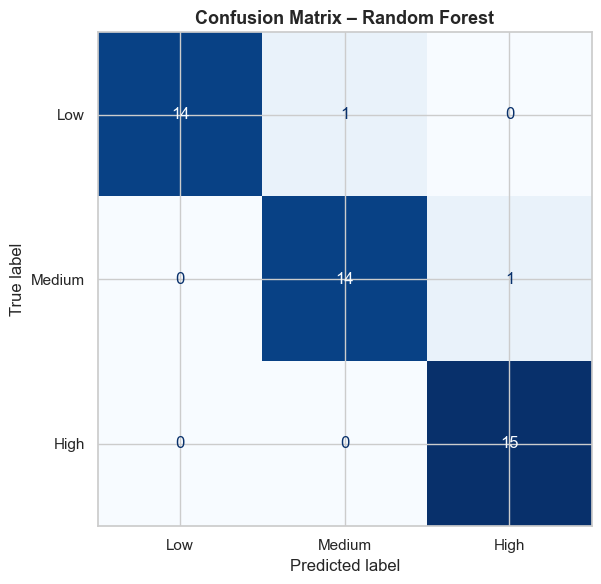

In [20]:
# Confusion Matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
print(cm)
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

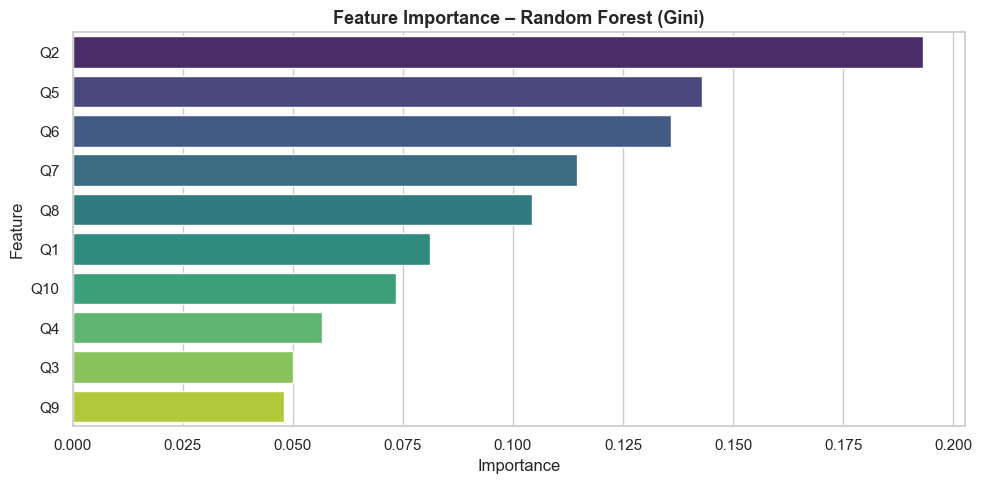

  feature  importance
0      Q2    0.193077
1      Q5    0.142918
2      Q6    0.135884
3      Q7    0.114483
4      Q8    0.104429
5      Q1    0.081166
6     Q10    0.073325
7      Q4    0.056566
8      Q3    0.050132
9      Q9    0.048020


In [21]:
# Native Feature Importance  (Gini impurity-based)
importances = rf_model.feature_importances_
feature_names = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=fi_df, palette='viridis')
plt.title('Feature Importance – Random Forest (Gini)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(fi_df)

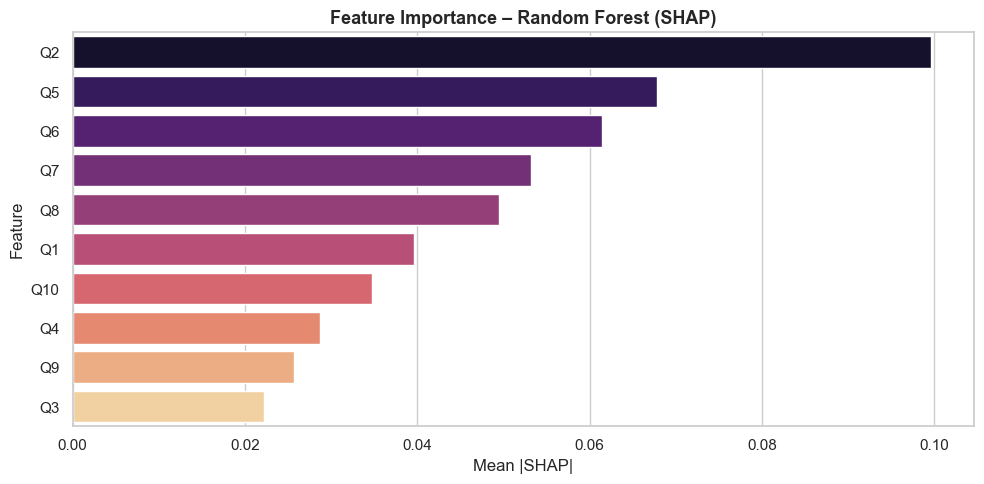

  feature  importance
0      Q2    0.099643
1      Q5    0.067811
2      Q6    0.061499
3      Q7    0.053174
4      Q8    0.049458
5      Q1    0.039656
6     Q10    0.034780
7      Q4    0.028714
8      Q9    0.025695
9      Q3    0.022170


In [22]:
# SHAP Explainability
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    # Older SHAP versions
    mean_shap_per_feature = np.mean(
        [np.abs(sv).mean(axis=0) for sv in shap_values],
        axis=0
    )
else:
    # Newer SHAP versions: (samples, features, classes)
    mean_shap_per_feature = np.abs(shap_values).mean(axis=(0, 2))

# Create feature importance dataframe
shap_fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_shap_per_feature
})

shap_fi_df = (
    shap_fi_df
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(
    data=shap_fi_df,
    x='importance',
    y='feature',
    palette='magma'
)

plt.title('Feature Importance – Random Forest (SHAP)',
          fontsize=13,
          fontweight='bold')
plt.xlabel('Mean |SHAP|')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(shap_fi_df)

In [23]:
# Save all artifacts to backend/ml_models/random_forest/
SAVE_DIR = '../backend/ml_models/random_forest'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save the model
joblib.dump(rf_model, os.path.join(SAVE_DIR, 'random_forest_model.pkl'))
print("Saved: random_forest_model.pkl")

# 2. Save X_train (needed for SHAP background)
joblib.dump(X_train, os.path.join(SAVE_DIR, 'X_train.pkl'))
print("Saved: X_train.pkl")

# 3. Save SHAP TreeExplainer
joblib.dump(explainer, os.path.join(SAVE_DIR, 'shap_explainer.pkl'))
print("Saved: shap_explainer.pkl")

# 4. Save evaluation metrics
eval_metrics = [
    {
        "model_name": "Random Forest",
    # NOTE: accuracy/f1/auc_roc/cv_mean/cv_std must come from the
    # variables computed in Cell 6 & 7 above (rf_model). If the JSON
    # on disk matches XGBoost values exactly, this cell was never
    # re-run after the initial copy-paste. Restart & Run All to fix.
        "accuracy": round(accuracy, 4),
        "f1_score": round(f1, 4),
        "auc_roc": round(auc_roc, 4),
        "cv_mean": round(cv_mean, 4),
        "cv_std": round(cv_std, 4)
    }
]
with open(os.path.join(SAVE_DIR, 'evaluation_metrics.json'), 'w') as f:
    json.dump(eval_metrics, f, indent=4)
print("Saved: evaluation_metrics.json")

# 5. Save SHAP-based feature importance
feature_importance_list = shap_fi_df.to_dict(orient='records')
with open(os.path.join(SAVE_DIR, 'feature_importance.json'), 'w') as f:
    json.dump(feature_importance_list, f, indent=4)
print("Saved: feature_importance.json")

print(f"\nAll artifacts saved to: {SAVE_DIR}")
print(f"\nFinal Metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC-ROC  : {auc_roc:.4f}")
print(f"  CV Mean  : {cv_mean:.4f} ± {cv_std:.4f}")

Saved: random_forest_model.pkl
Saved: X_train.pkl
Saved: shap_explainer.pkl
Saved: evaluation_metrics.json
Saved: feature_importance.json

All artifacts saved to: ../backend/ml_models/random_forest

Final Metrics:
  Accuracy : 0.9556
  F1 Score : 0.9555
  AUC-ROC  : 0.9993
  CV Mean  : 0.9732 ± 0.0326
